# Exploratory Data Analysis

### Setup

In [ ]:
%reload_ext autoreload
%autoreload 2

In [ ]:
# Setup working directory
from pathlib import Path
import os

def find_root_dir(marker='tfg'):
    p = Path.cwd()
    for candidate in [p] + list(p.parents):
        if candidate.name == marker:
            return candidate.resolve()
        if (candidate / marker).is_dir():
            return (candidate / marker).resolve()
    raise FileNotFoundError(f"Could not find '{marker}' folder in {Path.cwd()} or its parents.")

os.chdir(find_root_dir('tfg'))

In [ ]:
# Libraries for data manipulation and visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set Searborn style (background color, grid, axes, etc.) 
sns.set_style("whitegrid")

# Default values and styling for all plots
plt.rcParams.update({
    "figure.autolayout": True,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# Define custom colors
colors = ['crimson', 'lime']
palette = {
        'BENIGN': 'lime',
        'DDoS': 'crimson'
}

## Load and inspect data (`reference-8k-baseline`)

In [ ]:
REFERENCE_DATASET_PATH = "data/processed/stage1/reference-8k-baseline.parquet"

In [ ]:
from src.preprocessing import load_dataset
reference_df = load_dataset(REFERENCE_DATASET_PATH)
print("\nBasic Data Information:")
reference_df.info()
print("\nFirst few rows:")
reference_df.head()


Basic Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7997 entries, 0 to 7996
Data columns (total 75 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Flow ID                      7997 non-null   object 
 1   Source IP                    7997 non-null   object 
 2   Source Port                  7997 non-null   int32  
 3   Destination IP               7997 non-null   object 
 4   Destination Port             7997 non-null   int32  
 5   Protocol                     7997 non-null   int8   
 6   Timestamp                    7997 non-null   object 
 7   Flow Duration                7997 non-null   int32  
 8   Total Fwd Packets            7997 non-null   int16  
 9   Total Backward Packets       7997 non-null   int16  
 10  Total Length of Fwd Packets  7997 non-null   int32  
 11  Total Length of Bwd Packets  7997 non-null   int32  
 12  Fwd Packet Length Max        7997 non-null   int16 

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,172.16.0.1-192.168.10.50-59601-80-6,172.16.0.1,59601,192.168.10.50,80,6,7/7/2017 4:02,1148952,5,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
1,172.16.0.1-192.168.10.50-28809-80-6,172.16.0.1,28809,192.168.10.50,80,6,7/7/2017 4:07,8361212,4,0,...,20,581.0,0.0,581,581,8360631.0,0.0,8360631,8360631,DDoS
2,172.16.0.1-192.168.10.50-49759-80-6,172.16.0.1,49759,192.168.10.50,80,6,7/7/2017 3:56,1280276,2,5,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
3,172.16.0.1-192.168.10.50-60971-80-6,172.16.0.1,60971,192.168.10.50,80,6,7/7/2017 4:12,78218,3,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
4,192.168.10.3-192.168.10.9-53-51832-17,192.168.10.9,51832,192.168.10.3,53,17,7/7/2017 4:16,223,2,2,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


Label
DDoS      3999
BENIGN    3998
Name: count, dtype: int64


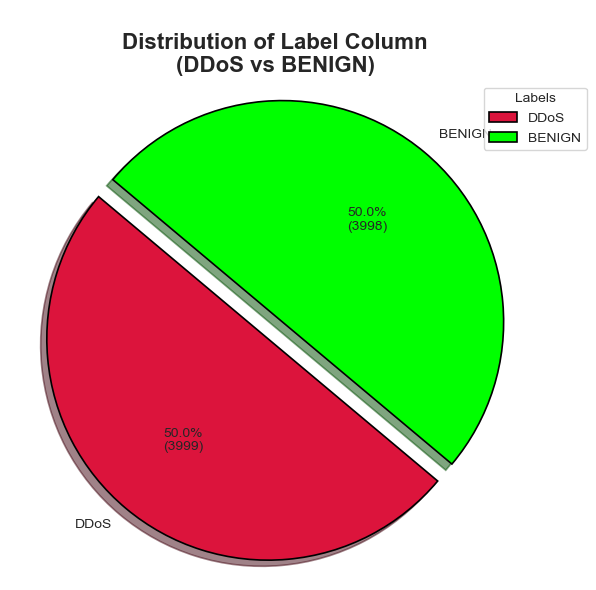

In [ ]:
def plot_class_distribution(label_counts):  
    plt.figure(figsize=(6, 6))
    plt.pie(
        label_counts,                                                               # Values for each slice
        labels=label_counts.index,                                                  # Labels for each slice                                
        autopct=lambda pct: f"{pct:.1f}%\n({int(pct/100.*sum(label_counts))})",     # Show both percentage and count
        startangle=140, 
        colors=colors, 
        explode=(0.1,0), 
        shadow=True, 
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.2}
    )

    plt.title('\nDistribution of Label Column\n(DDoS vs BENIGN)', fontsize=16, fontweight='bold')
    plt.axis('equal')
    plt.legend(label_counts.index, title="Labels", loc="upper right", bbox_to_anchor=(1.1, 1))

    plt.show()

# Calculate label counts
plot_class_distribution(reference_df['Label'].value_counts())

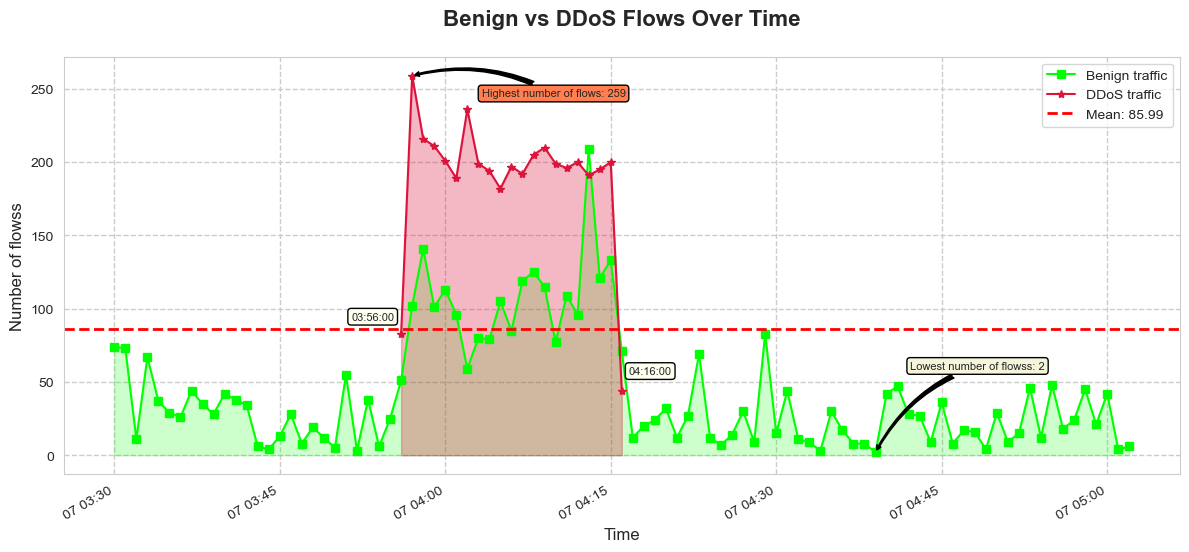

In [ ]:
def plot_benign_ddos_over_time(flows_by_time_benign, flows_by_time_ddos, df_sorted):
    # -----------------------------------------------------------------------------
    # 1.3.3. Combined plot for Benign vs DDoS traffic over time
    # -----------------------------------------------------------------------------
    plt.figure(figsize=(12, 6))
    plt.plot(
        flows_by_time_benign.index,    # X-axis: Timestamps
        flows_by_time_benign.values,   # Y-axis: Number of benign flowss
        marker='s', 
        linestyle='-',
        color='lime', 
        label='Benign traffic'
    )
    plt.plot(
        flows_by_time_ddos.index,      # X-axis: Timestamps
        flows_by_time_ddos.values,     # Y-axis: Number of DDoS flowss
        marker='*', 
        linestyle='-',
        color='crimson', 
        label='DDoS traffic'
    )

    plt.title('Benign vs DDoS Flows Over Time\n', fontsize=16, fontweight='bold')
    plt.xlabel('Time')
    plt.ylabel('Number of flowss')
    plt.grid(axis='both', which='major', linestyle='--', linewidth=1)

    counts = pd.crosstab(df_sorted['Timestamp'], df_sorted['Label']).sort_index()
    counts['DDoS'] = counts.drop(columns=['BENIGN'], errors='ignore').sum(axis=1)
    counts['BENIGN'] = counts.get('BENIGN', 0)  
    counts['TOTAL'] = counts['BENIGN'] + counts['DDoS']   
    mean_total = counts['TOTAL'].mean()

    plt.axhline(y=mean_total, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_total:.2f}")


    plt.fill_between(flows_by_time_benign.index, flows_by_time_benign.values,
                    interpolate=True, color='lime', alpha=0.2)

    plt.fill_between(flows_by_time_ddos.index, flows_by_time_ddos.values,
                    interpolate=True, color='crimson', alpha=0.3)


    # Annotate min value for Benign
    min_idx = flows_by_time_benign.idxmin()
    min_value = flows_by_time_benign.min()

    plt.annotate(
        f'Lowest number of flowss: {min_value}', 
        xy=(min_idx, min_value), 
        xytext=( 25, 60),
        textcoords='offset points', 
        arrowprops=dict(arrowstyle='fancy', color='black', connectionstyle='arc3,rad=0.2'),
        bbox=dict(boxstyle="round,pad=0.3", fc="beige", ec="black"),
        fontsize=8,
        ha="left"
    )

    # Annotate max value for DDoS
    max_idx = flows_by_time_ddos.idxmax()
    max_value = flows_by_time_ddos.max()
    plt.annotate(
        f'Highest number of flows: {max_value}', 
        xy=(max_idx, max_value), 
        xytext=( 50, -15),
        textcoords='offset points', 
        arrowprops=dict(arrowstyle='fancy', color='black', connectionstyle='arc3,rad=0.2'),
        bbox=dict(boxstyle="round,pad=0.3", fc="coral", ec="black"),
        fontsize=8,
        ha="left"
    )




    # Annotate start time for DDoS traffic
    start_time_ddos_index=flows_by_time_ddos.index.min()
    start_time_ddos_value=flows_by_time_ddos[start_time_ddos_index]
    plt.annotate(
        f'{start_time_ddos_index.strftime('%H:%M:%S')}', 
        xy=(start_time_ddos_index, start_time_ddos_value), 
        xytext=( -5, 10),
        textcoords='offset points', 
        bbox=dict(boxstyle="round,pad=0.3", fc="ivory", ec="black"),
        fontsize=8,
        ha="right"
    )

    # Annotate end time for DDoS traffic
    end_time_ddos_index=flows_by_time_ddos.index.max()
    end_time_ddos_value=flows_by_time_ddos[end_time_ddos_index]
    plt.annotate(
        f'{end_time_ddos_index.strftime('%H:%M:%S')}', 
        xy=(end_time_ddos_index, end_time_ddos_value), 
        xytext=( 5, 12),
        textcoords='offset points', 
        bbox=dict(boxstyle="round,pad=0.3", fc="ivory", ec="black"),
        fontsize=8,
        ha="left"
    )


    plt.legend()
    plt.tight_layout()
    plt.gcf().autofmt_xdate()
    plt.show()


# Convert Timestamp to datetime
reference_df['Timestamp'] = pd.to_datetime(reference_df['Timestamp'])

reference_df_sorted = reference_df.sort_values(
    'Timestamp',   # Sort Dataframe in ascending order
    inplace=False  # Dont modify original Dataframe
)
flows_by_time_benign=reference_df_sorted[reference_df_sorted['Label']=='BENIGN'].groupby('Timestamp').size()
flows_by_time_ddos=reference_df_sorted[reference_df_sorted['Label']!='BENIGN'].groupby('Timestamp').size()
plot_benign_ddos_over_time(flows_by_time_benign, flows_by_time_ddos, reference_df_sorted)

## Load and inspect data (`full-225k-baseline`)

In [ ]:
FULL_DATASET_PATH = "data/processed/stage2/full-225k-baseline.parquet"

In [ ]:
from src.preprocessing import load_dataset
full_df = load_dataset(FULL_DATASET_PATH)
print("\nBasic Data Information:")
full_df.info()
print("\nFirst few rows:")
full_df.head()


Basic Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225603 entries, 0 to 225602
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Flow ID                      225603 non-null  object 
 1   Source IP                    225603 non-null  object 
 2   Source Port                  225603 non-null  int32  
 3   Destination IP               225603 non-null  object 
 4   Destination Port             225603 non-null  int32  
 5   Protocol                     225603 non-null  int8   
 6   Timestamp                    225603 non-null  object 
 7   Flow Duration                225603 non-null  int32  
 8   Total Fwd Packets            225603 non-null  int16  
 9   Total Backward Packets       225603 non-null  int16  
 10  Total Length of Fwd Packets  225603 non-null  int32  
 11  Total Length of Bwd Packets  225603 non-null  int32  
 12  Fwd Packet Length Max        2256

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,92.168.10.5-104.16.207.165-54865-4143-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### Feature Taxonomy
1. **Type**-based Taxonomy:
    - Categorical Features
    - Discrete Features
    - Continuous Features

2. **Traffic**-based Taxonomy:
    - Flow Identification Features
    - Traffic Volume Features
    - Packet Size Distribution Features
    - Time-related Features
    - Traffic Rate Features
    - TCP Flags Features
    - Header Features Features
    - Bulk Transfer Features
    - TCP Window Features
    - Connection Features

In [ ]:
from src.utils import intro

# Categorical features: object or category dtype
categorical_features = [col for col in full_df.columns if full_df[col].dtype == 'object' or full_df[col].dtype.name == 'category']
## Manually add 'Source Port', 'Destination Port', 'Protocol' to categorical features
categorical_features.append('Source Port')
categorical_features.append('Destination Port')
categorical_features.append('Protocol')

# Discrete features: int8, int16, int32, int64 dtype
discrete_features = [col for col in full_df.columns if (full_df[col].dtype == 'int8' or full_df[col].dtype == 'int16' or full_df[col].dtype == 'int32') and col not in categorical_features]

# Continuous features: float32, float64 dtype
continuous_features = [col for col in full_df.columns if full_df[col].dtype == 'float64' or full_df[col].dtype == 'float32']

intro("Type Feature Groups Summary")
print("\nCategorical Features ({})".format(len(categorical_features)), categorical_features)
print("\nDiscrete Features ({})".format(len(discrete_features)), discrete_features)
print("\nContinuous Features ({})".format(len(continuous_features)), continuous_features)


Type Feature Groups Summary

Categorical Features (8) ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Label', 'Source Port', 'Destination Port', 'Protocol']

Discrete Features (43) ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Min Packet Length', 'Max Packet Length', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Acti

In [ ]:
traffic_feature_groups = {
    "Traffic Volume Features": [
        "Total Fwd Packets",
        "Total Backward Packets",
        "Total Length of Fwd Packets",
        "Total Length of Bwd Packets",
        "Subflow Fwd Packets",
        "Subflow Fwd Bytes",
        "Subflow Bwd Packets",
        "Subflow Bwd Bytes"
    ],
    "Packet Size Distribution Features": [
        "Fwd Packet Length Max",
        "Fwd Packet Length Min",
        "Fwd Packet Length Mean",
        "Fwd Packet Length Std",
        "Bwd Packet Length Max",
        "Bwd Packet Length Min",
        "Bwd Packet Length Mean",
        "Bwd Packet Length Std",
        "Min Packet Length",
        "Max Packet Length",
        "Packet Length Mean",
        "Packet Length Std",
        "Packet Length Variance",
        "Average Packet Size",
        "Avg Fwd Segment Size",
        "Avg Bwd Segment Size"
    ],
    "Time-related Features": [
        "Flow Duration",
        "Flow IAT Mean",
        "Flow IAT Std",
        "Flow IAT Max",
        "Flow IAT Min",
        "Fwd IAT Total",
        "Fwd IAT Mean",
        "Fwd IAT Std",
        "Fwd IAT Max",
        "Fwd IAT Min",
        "Bwd IAT Total",
        "Bwd IAT Mean",
        "Bwd IAT Std",
        "Bwd IAT Max",
        "Bwd IAT Min",
        "Active Mean",
        "Active Std",
        "Active Max",
        "Active Min",
        "Idle Mean",
        "Idle Std",
        "Idle Max",
        "Idle Min"
    ],
    "Traffic Rate Features": [
        "Flow Bytes/s",
        "Flow Packets/s",
        "Fwd Packets/s",
        "Bwd Packets/s"
    ],
    "TCP Flag Features": [
        "FIN Flag Count",
        "SYN Flag Count",
        "RST Flag Count",
        "PSH Flag Count",
        "ACK Flag Count",
        "URG Flag Count",
        "CWE Flag Count",
        "ECE Flag Count",
        "Fwd PSH Flags",
        "Bwd PSH Flags",
        "Fwd URG Flags",
        "Bwd URG Flags"
    ],
    "Header Features": [
        "Fwd Header Length",
        "Bwd Header Length",
        "Fwd Header Length.1"
    ],
    "Bulk Transfer Features": [
        "Fwd Avg Bytes/Bulk",
        "Fwd Avg Packets/Bulk",
        "Fwd Avg Bulk Rate",
        "Bwd Avg Bytes/Bulk",
        "Bwd Avg Packets/Bulk",
        "Bwd Avg Bulk Rate"
    ],
    "TCP Window Features": [
        "Init_Win_bytes_forward",
        "Init_Win_bytes_backward"
    ],
    "Connection Features": [
        "Down/Up Ratio",
        "act_data_pkt_fwd",
        "min_seg_size_forward"
    ]
}

intro("Traffic Feature Groups Summary")
total_features = 0
print(f"Total number of features: {total_features}")
print(f"Number of feature groups: {len(traffic_feature_groups)}\n")
for group_name, features in traffic_feature_groups.items():
    n_features = len(features)
    total_features += n_features
    print(f"- {group_name:<30}: {n_features:2d} features")


Traffic Feature Groups Summary
Total number of features: 0
Number of feature groups: 9

- Traffic Volume Features       :  8 features
- Packet Size Distribution Features: 16 features
- Time-related Features         : 23 features
- Traffic Rate Features         :  4 features
- TCP Flag Features             : 12 features
- Header Features               :  3 features
- Bulk Transfer Features        :  6 features
- TCP Window Features           :  2 features
- Connection Features           :  3 features


### Class distribution

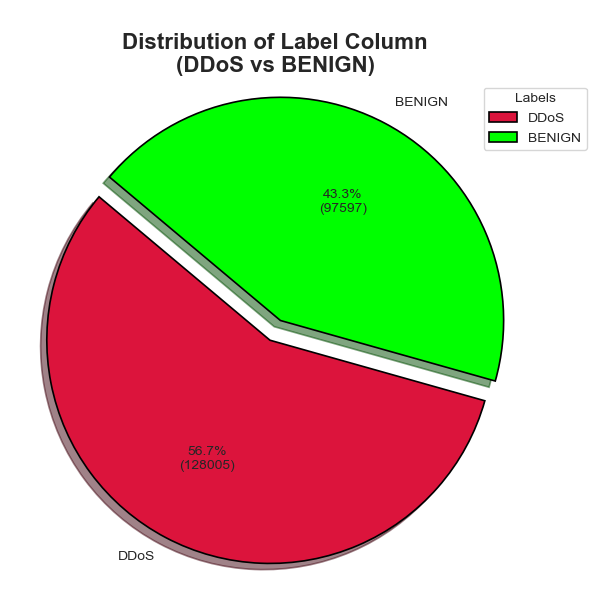

In [ ]:
plot_class_distribution(full_df['Label'].value_counts())

### Traffic analysis over time

In [ ]:
full_df['Timestamp'] = pd.to_datetime(full_df['Timestamp'])

full_df_sorted = full_df.sort_values(
    'Timestamp',   # Sort Dataframe in ascending order (from 07.07 03:30 to 07.07 05:00)
    inplace=False  
)

In [ ]:
def temporal_analysis(flows, connection_type, color):
    plt.figure(figsize=(12, 6))
    plt.plot(
        flows.index,     # X-axis: Timestamps
        flows.values,    # Y-axis: Number of flows
        marker='s', 
        linestyle='-',
        color=color, 
        label=f'{connection_type} traffic'
    )

    plt.title(f'\n{connection_type} Flows Over Time\n', fontsize=16, fontweight='bold')
    plt.xlabel('Time')
    plt.ylabel('Number of flows')
    plt.grid(axis='both', which='major', linestyle='--', linewidth=1)

    # Annotate max, min, and mean values
    max_idx = flows.idxmax()
    max_value = flows.max()
    min_idx = flows.idxmin()
    min_value = flows.min()
    mean_value = flows.mean()

    # Add horizontal line for mean value
    plt.axhline(
        y=mean_value, 
        color='red', 
        linestyle='--', 
        linewidth=2, 
        label=f"Mean: {mean_value:.2f}"
    )

    # Annotate max value
    plt.annotate(
        f'Highest number of flows: {max_value}', 
        xy=(max_idx, max_value), 
        xytext=( 50, -15),
        textcoords='offset points', 
        arrowprops=dict(arrowstyle='fancy', color='black', connectionstyle='arc3,rad=0.2'),
        bbox=dict(boxstyle="round,pad=0.3", fc="beige", ec="black"),
        fontsize=10,
        ha="left"
    )

    # Annotate min value
    plt.annotate(
        f'Lowest number of flows: {min_value}', 
        xy=(min_idx, min_value), 
        xytext=( 25, 100),
        textcoords='offset points', 
        arrowprops=dict(arrowstyle='fancy', color='black', connectionstyle='arc3,rad=0.2'),
        bbox=dict(boxstyle="round,pad=0.3", fc="beige", ec="black"),
        fontsize=10,
        ha="left"
    )

    plt.tight_layout()
    plt.gcf().autofmt_xdate()
    plt.legend()
    plt.show()

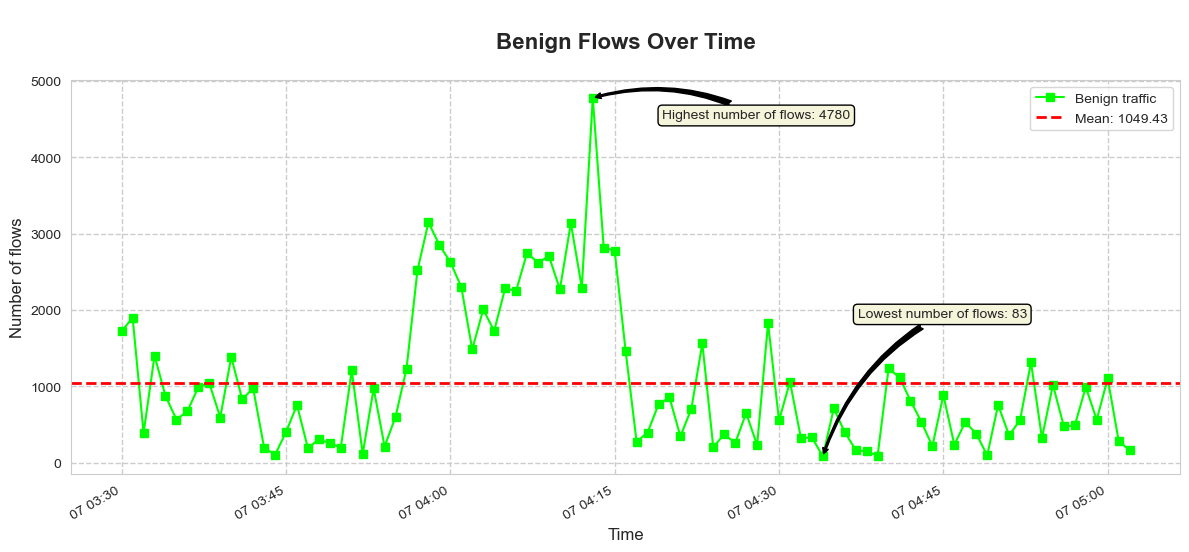

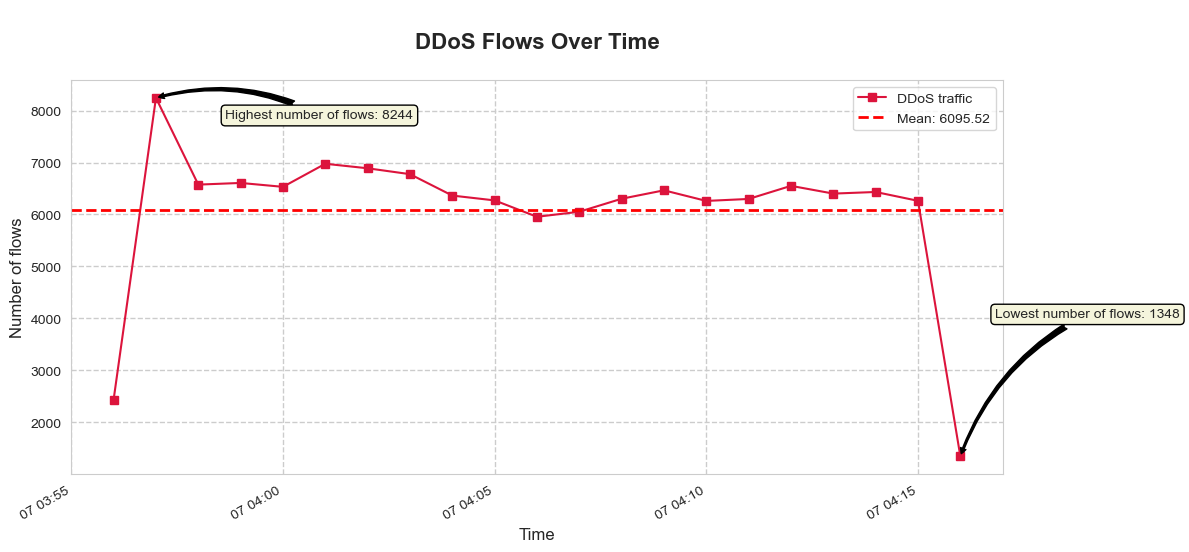

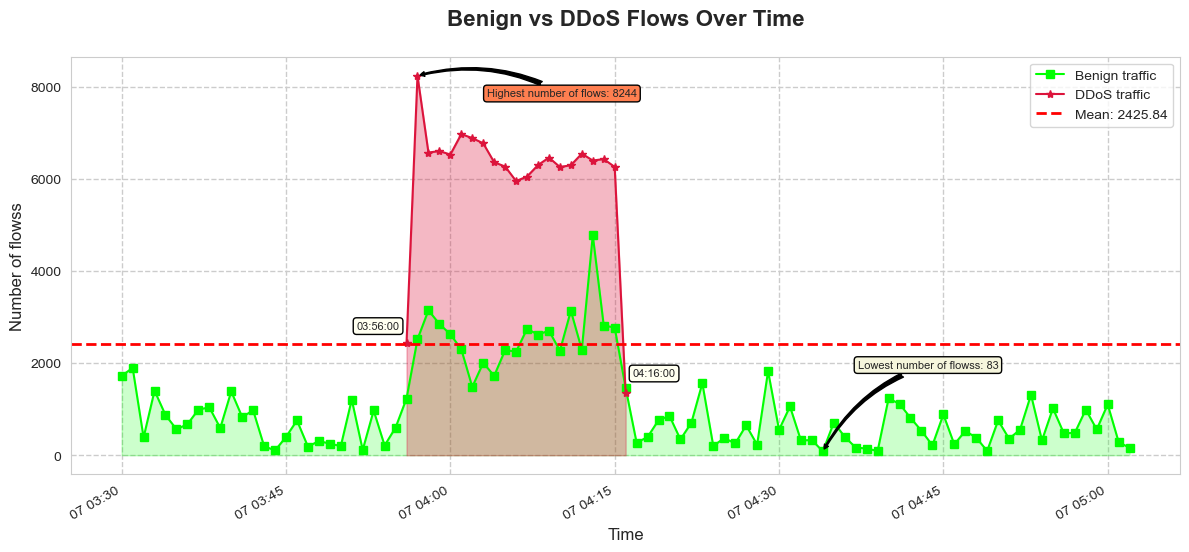

In [ ]:
flows_by_time_benign=full_df_sorted[full_df_sorted['Label']=='BENIGN'].groupby('Timestamp').size()
temporal_analysis(flows_by_time_benign, 'Benign', colors[1])
flows_by_time_ddos=full_df_sorted[full_df_sorted['Label']!='BENIGN'].groupby('Timestamp').size()
temporal_analysis(flows_by_time_ddos, 'DDoS', colors[0])
plot_benign_ddos_over_time(flows_by_time_benign, flows_by_time_ddos, full_df_sorted)

### Analysis of key features

---

In [ ]:
def plot_categorical_features(df, label, features_names=None, top_n_values=5, c='lime'):

    if features_names is None or label is None:
        raise ValueError("features_names or label is None. Please provide valid values for both parameters.") 
    
    # Rows and columns needed
    n = len(features_names)
    cols = 2
    rows = (n + cols - 1) // cols

    fig, axs = plt.subplots(rows, cols, figsize=(12, 13))
    axs = axs.flatten()


    data = df.loc[df["Label"] == label, features_names]

    for i, column in enumerate(features_names):
        counts = data[column].value_counts().head(top_n_values)
        labels = counts.index.astype(str)
        values = counts.values

        sns.barplot(
            x=labels, 
            y=values, 
            ax=axs[i], 
            color=c,
            dodge=False,
            legend=False
        )

        # Add count values on top of the bars
        for container in axs[i].containers:
            axs[i].bar_label(container, label_type='edge', padding=2)

        axs[i].set_title(f"\n{column} Distribution ({label} Traffic)\n", fontsize=12, fontweight="bold")
        axs[i].set_xlabel("")
        axs[i].set_ylabel("Count")
        axs[i].set_xticks(ticks=axs[i].get_xticks(), labels=labels, rotation=45)

    # Delete any unused subplots
    for j in range(len(features_names), len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

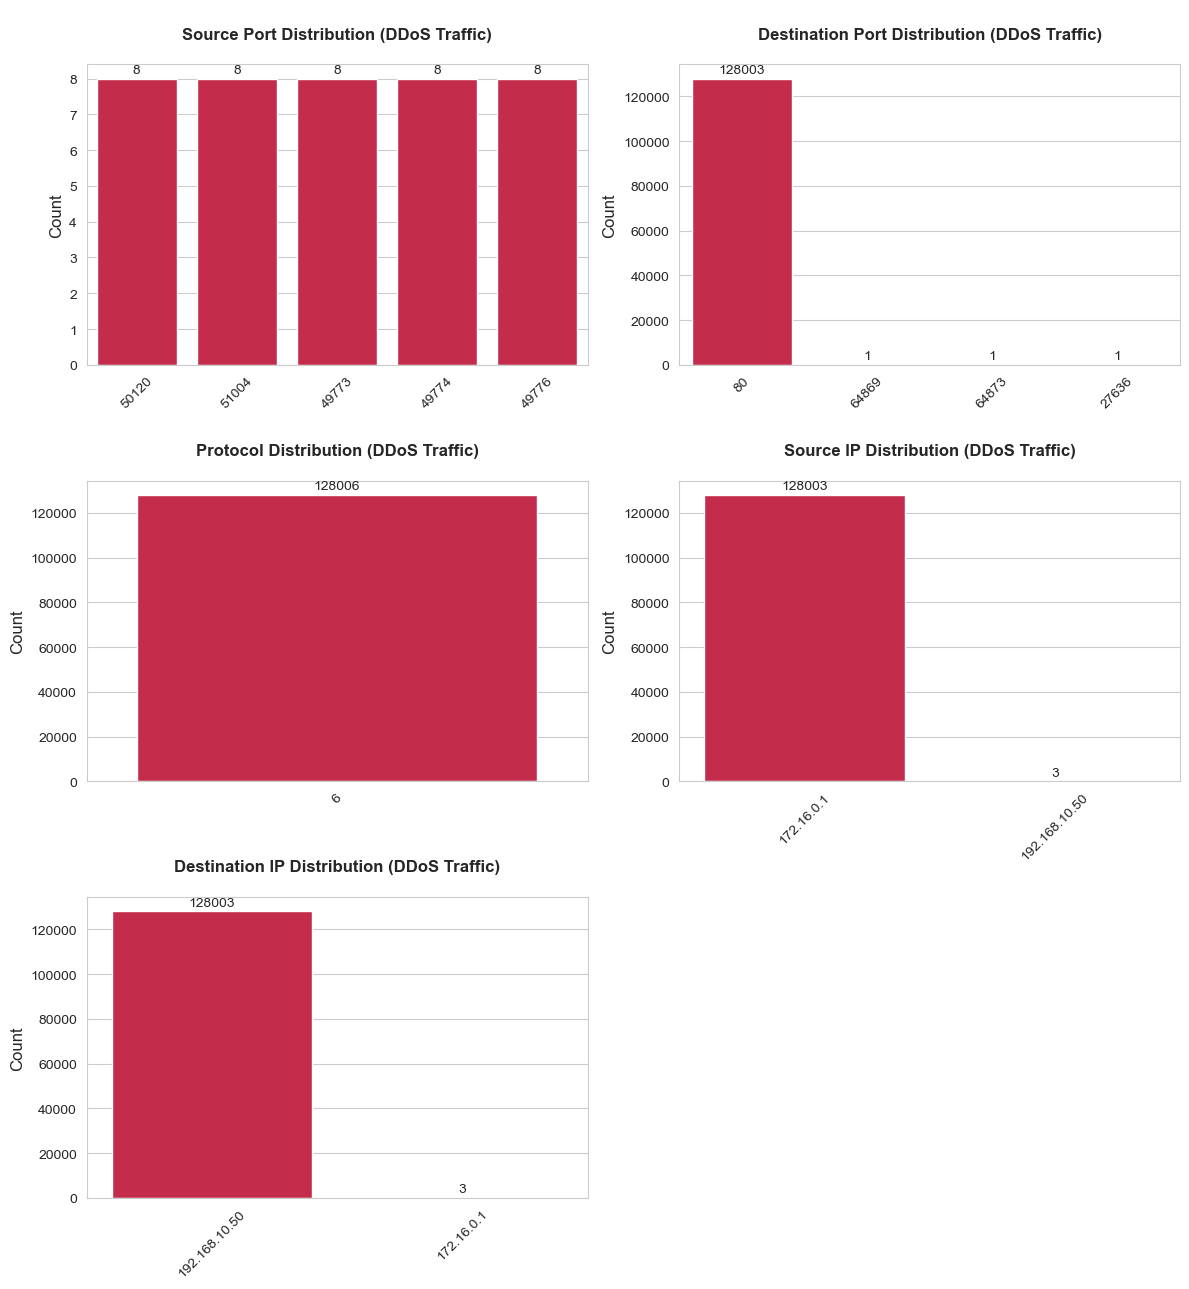

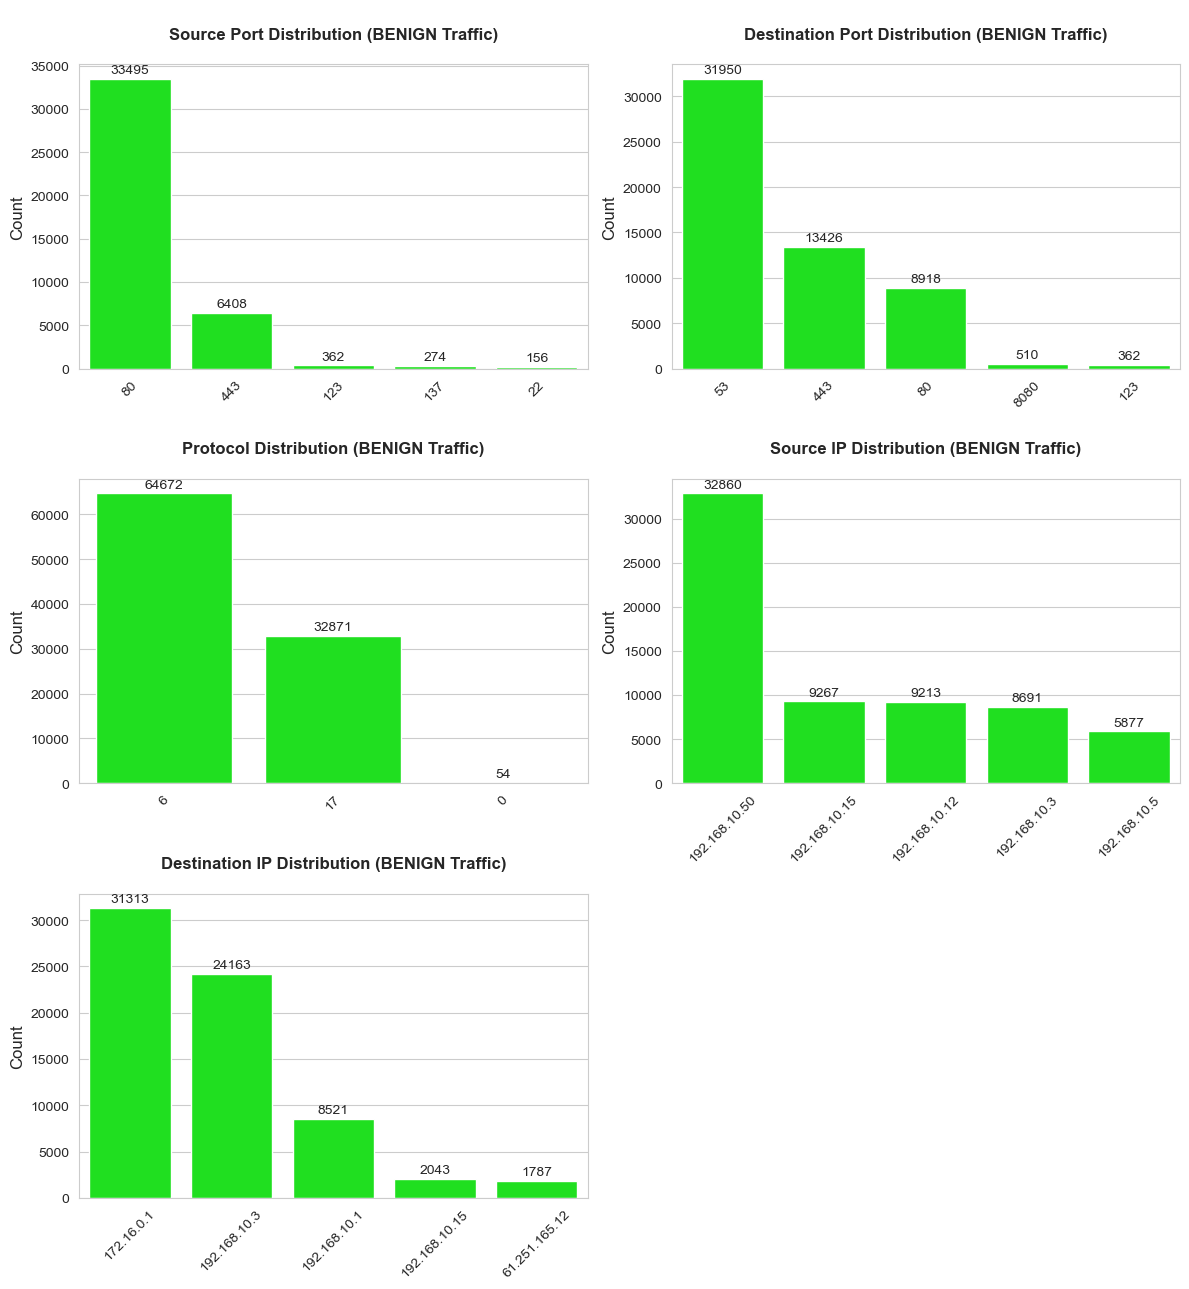

In [ ]:
top_n_values = 5
features_names = ['Source Port', 'Destination Port', 'Protocol', 'Source IP', 'Destination IP']
labels_colors = [('DDoS', 'crimson'), ('BENIGN', 'lime')]

for label, color in labels_colors:
        plot_categorical_features(full_df, label, features_names, top_n_values, c=color)

##### DDoS traffic characteristics
- Affected service: port 80 (**HTTP**)  
- Protocol used by the attacker: 6 (TCP)  
- Attacker IP: 172.16.0.1  
- Victim IP: 192.168.10.50  

##### Benign traffic characteristics
- Specific ports: 80 (HTTP), 53 (DNS), 443 (HTTPS)  
- Specific protocols: 6 (TCP) and 17 (UDP)  
- Legitimate user IPs: 192.168.10.50, 192.168.10.15, 192.168.10.12 ...
- Most of the benign requests are sent to the attacker IP (172.16.0.1)

### Statistical analysis over numeric traffic features

---

In [ ]:
def describe_analysis(df, feature_groups, decimals=2):
    if feature_groups is None:
        raise ValueError("feature_groups cannot be None.")

    for group_name, features in feature_groups.items():
        # Keep only existing columns
        existing = [f for f in features if f in df.columns]
        if not existing:
            continue
        intro(group_name)
        summary = (
            df[existing]
            .describe()
            .T
            .round(decimals)
        )
        print(summary)

describe_analysis(full_df, traffic_feature_groups, decimals=3)

Traffic Volume Features
                                count      mean        std  min   25%    50%  \
Total Fwd Packets            225603.0     4.811     13.474  1.0   2.0    3.0   
Total Backward Packets       225603.0     4.473     17.979  0.0   1.0    4.0   
Total Length of Fwd Packets  225603.0   936.452   3222.300  0.0  26.0   30.0   
Total Length of Bwd Packets  225603.0  5782.877  32662.349  0.0   0.0  164.0   
Subflow Fwd Packets          225603.0     4.811     13.474  1.0   2.0    3.0   
Subflow Fwd Bytes            225603.0   936.452   3222.300  0.0  26.0   30.0   
Subflow Bwd Packets          225603.0     4.473     17.979  0.0   1.0    4.0   
Subflow Bwd Bytes            225603.0  5782.877  32662.349  0.0   0.0  164.0   

                                 75%        max  
Total Fwd Packets                5.0     1932.0  
Total Backward Packets           5.0     2881.0  
Total Length of Fwd Packets     63.0   120783.0  
Total Length of Bwd Packets  11601.0  5172346.0  
Subfl

**Analysis**: 
- Traffic Volume Features: the respective *Total* and *Subflow* features have identical statistics across all measures. They contain redundant information. 
- Packet Size Distribution Features present broad range of values due to high *std*. Several features have minimum and first quantile (*Q1*) equal to zero, indicating that a 25% of flows contain zero-valued packet statistics. 
- Time-related Features also present wide range of values. *Active* and *Idle* features have highly skewed distributions because most of the values are concentrated over the third quantile (Q3). 
- Again, Traffic Rate Features present a variate range of values.
- TCP Flag Features contribute little information due to their low variability. FIN, RST and ECE flags are nearly constant.
- Header Features: `Fwd Header Length` and `Fwd Header Length.1` have identical measures. `Fwd Header Length.1` is a duplicate feature. 

**Key Takeaways**: Feature values span very different numerical ranges, making **standarization** necessary before training scale-sensitive models. Long-tailed feature distributions should be examined through boxplots. TCP Flag Features with low variability should be evaluated for removal. Duplicated or statistically identical features should be examined through a correlation analysis.

#### TCP Flag Features Analysis

TCP Flag Feature Distribution


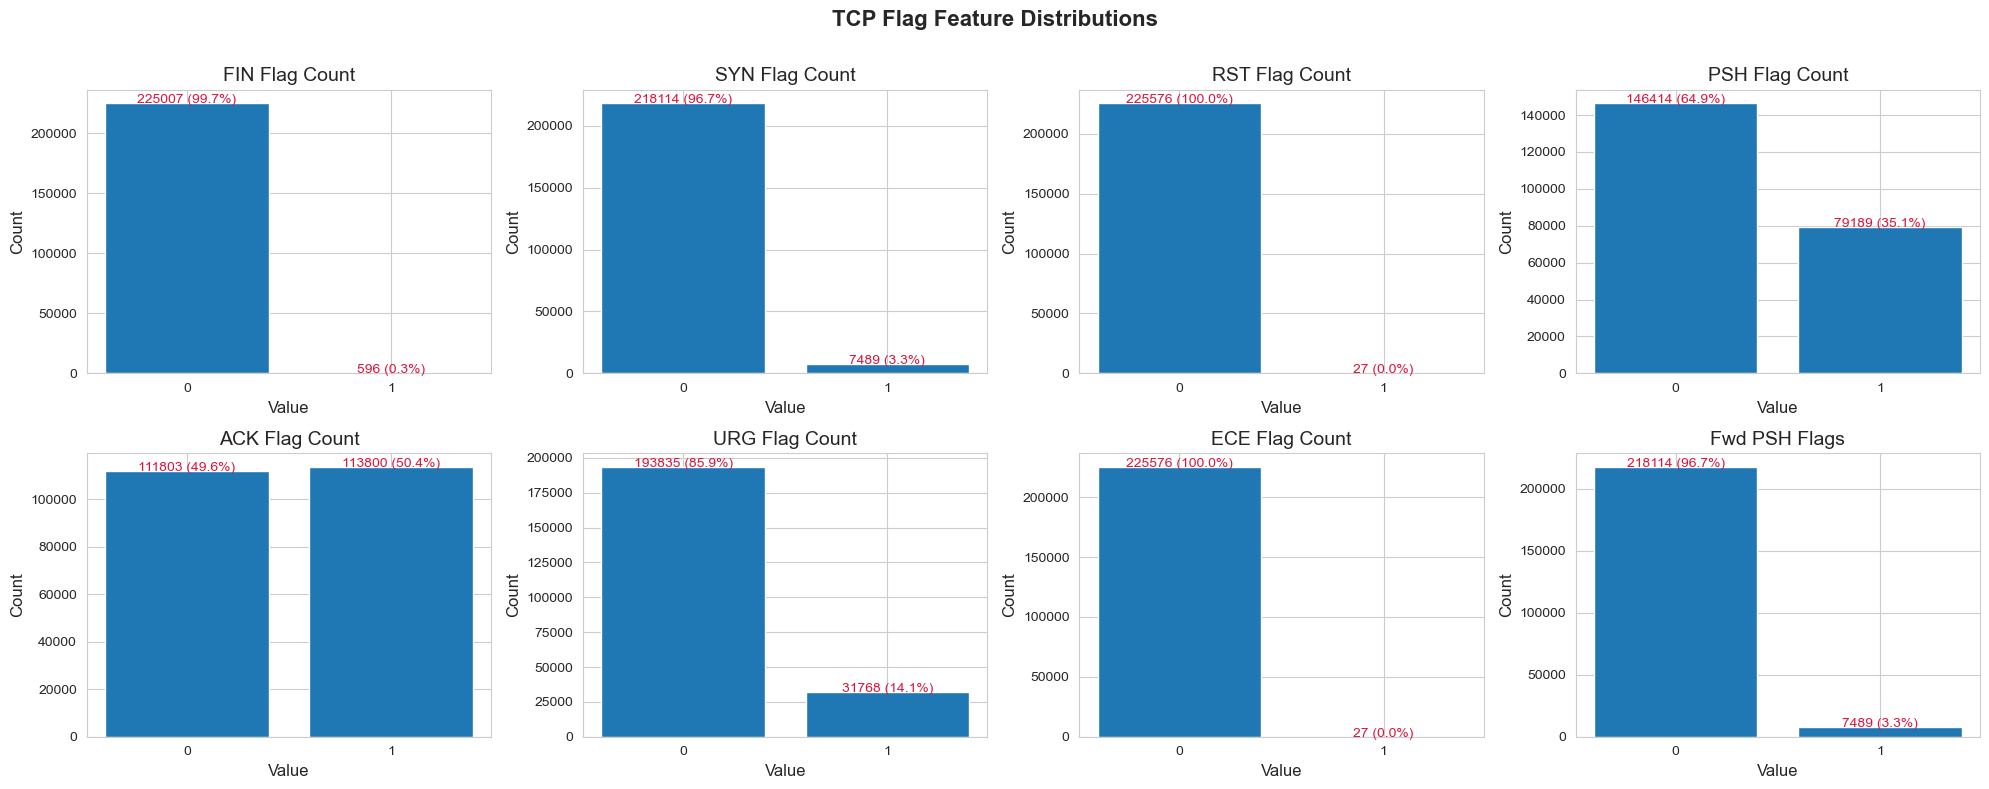

In [ ]:
import math 

def tcp_flag_analysis(df, feature_groups):
    intro("TCP Flag Feature Distribution")

    tcp_flag_features = [
        f for f in feature_groups["TCP Flag Features"]
        if f in df.columns
    ]

    cols = 4
    rows = math.ceil(len(tcp_flag_features) / cols)
    fig, axs = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axs = axs.flatten()
    n = len(df)

    for i, column in enumerate(tcp_flag_features):
        counts = df[column].value_counts().sort_index()
        ax = axs[i]
        bars = ax.bar(
            counts.index.astype(str),
            counts.values,)
        ax.set_title(column,)
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")

        # Annotate count and percentage
        for bar, count in zip(bars, counts.values):
            pct = 100 * count / n
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{count} ({pct:.1f}%)",
                ha="center",
                color="crimson"
            )

    fig.suptitle("TCP Flag Feature Distributions\n", fontsize=16, fontweight="bold")
    plt.show()
    
tcp_flag_analysis(full_df, traffic_feature_groups)

**Analysis**: `SYN Flag Count` and `Fwd PSH Flags` have identical values, thus one of then will be dropped. Confirmation of nearly constant columns with `{FIN, RST and ECE} Flag Count`. `URG Flag Count` and `SYN Flag Count` or `ACK Flag Count` may provide information to the model despite its imbalance. 

**Key Takeaways**: `PSH Flag Count` and `ACK Flag Count` are the most likely to contribute **useful** information for the model. 

#### TCP Window Features Analysis

TCP Window Feature Analysis
Init_Win_bytes_forward: 32925 negative values (14.59%)


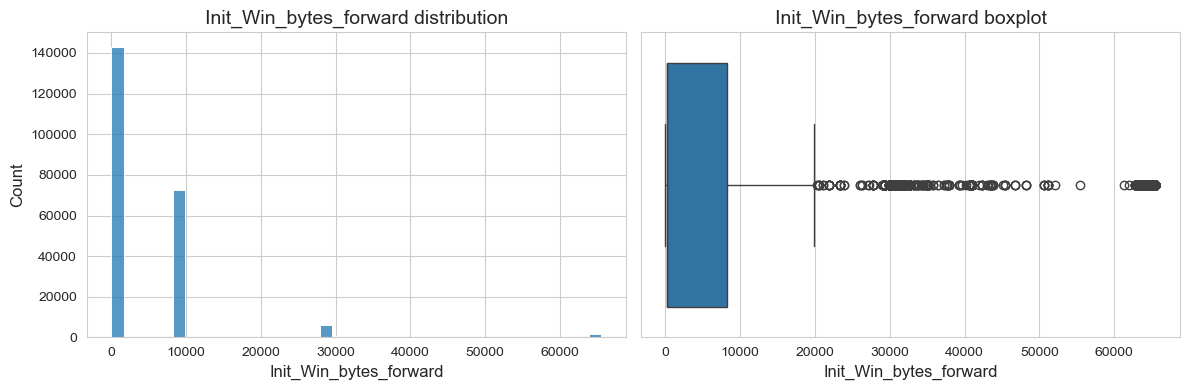

Init_Win_bytes_backward: 88274 negative values (39.13%)


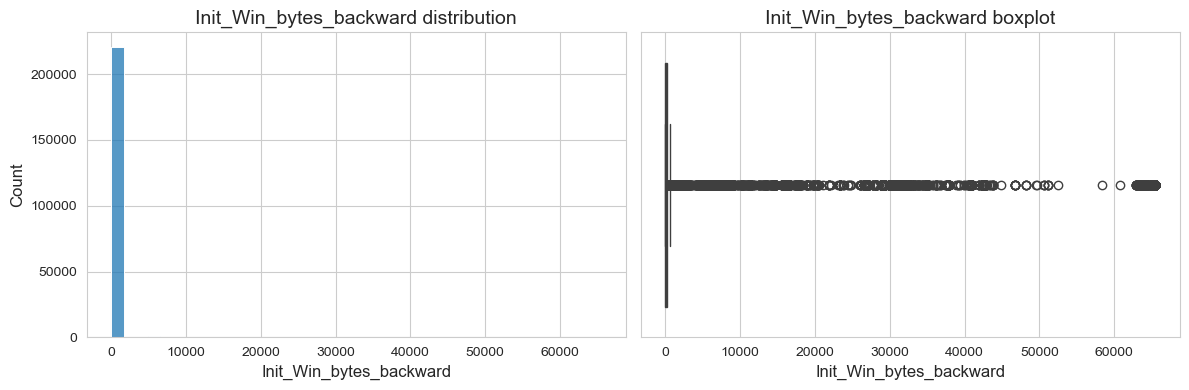

In [ ]:
def tcp_window_analysis(df):
    features = [
        "Init_Win_bytes_forward",
        "Init_Win_bytes_backward"
    ]
    features = [f for f in features if f in df.columns]

    intro("TCP Window Feature Analysis")

    for feature in features:
        count_minus_one = (df[feature] == -1).sum()
        percentage_minus_one = 100 * count_minus_one / len(df)
        print(f"{feature}: {count_minus_one} negative values ({percentage_minus_one:.2f}%)")

        print("=" * 60)
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(df[feature], bins=40, ax=ax[0])
        ax[0].set_title(f"{feature} distribution")
        sns.boxplot(x=df[feature], ax=ax[1])
        ax[1].set_title(f"{feature} boxplot")
        plt.show()

tcp_window_analysis(full_df)

**Key Takeaway**: The TCP Window features will be dropped. Although they contain protocol-level information, the presence of negative values, particularly -1, violates the expected logical constraints of TCP window size, which should be non-negative. Since these values may result from an issue in the feature extraction process rather than representing meaningful network traffic information, retaining the features could introduce misleading patterns into the models.

#### Active/Idle Features Analysis

Active / Idle Feature Analysis

Active Mean
------------------------------------------------------------
Zero values: 145448 (64.47%)

Active Std
------------------------------------------------------------
Zero values: 219945 (97.49%)


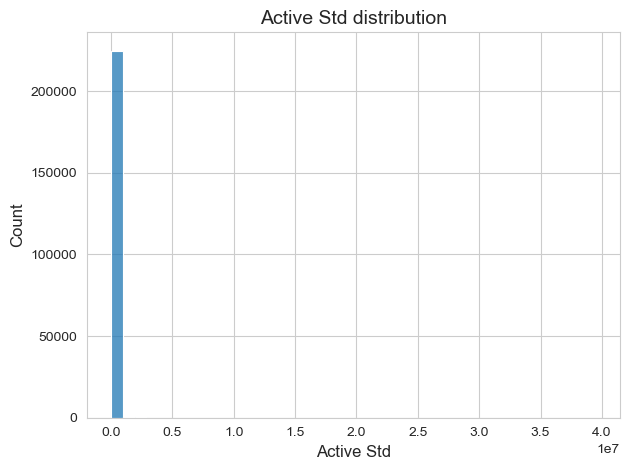


Active Max
------------------------------------------------------------
Zero values: 145448 (64.47%)

Active Min
------------------------------------------------------------
Zero values: 145448 (64.47%)

Idle Mean
------------------------------------------------------------
Zero values: 145389 (64.44%)

Idle Std
------------------------------------------------------------
Zero values: 203098 (90.02%)


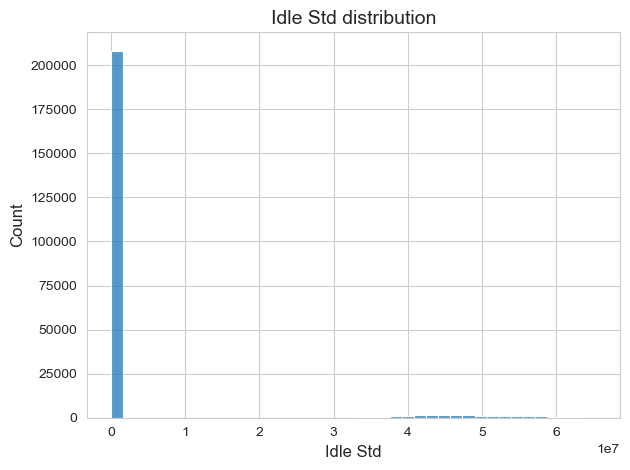


Idle Max
------------------------------------------------------------
Zero values: 145389 (64.44%)

Idle Min
------------------------------------------------------------
Zero values: 145389 (64.44%)


In [ ]:
def active_idle_analysis(df):
    features = [
        "Active Mean", "Active Std", "Active Max", "Active Min",
        "Idle Mean", "Idle Std", "Idle Max", "Idle Min"
    ]

    features = [f for f in features if f in df.columns]

    intro("Active / Idle Feature Analysis")

    for feature in features:

        zeros = (df[feature] == 0).sum()
        pct = 100 * zeros / len(df)

        print(f"\n{feature}")
        print("-" * 60)
        print(f"Zero values: {zeros} ({pct:.2f}%)")

        # Features above 90% of zero values
        if pct >= 90:
            sns.histplot(df[feature], bins=40)
            plt.title(f"{feature} distribution")
            plt.show()
active_idle_analysis(full_df)

**Key Takeaway**: ``Idle Std`` and ``Active Std`` present 97% and 90% respectivelly of zero values, thus they provide no information to the model. 

#### Conclusion

- Near-zero variance features and duplicate features provide no discriminative information and unnecessarily increase the dimensionality of the dataset. 
- TCP Window Features violate logical constraints as they have negative values.

---

Drop `Fwd PSH Flags`,`FIN Flag Count`,`RST Flag Count`,`ECE Flag Count`, `Active Std`, `Idle Std`, `Init_Win_bytes_forward`, `Init_Win_bytes_backward` on feature selection

### Distribution Analysis Through Boxplots

---

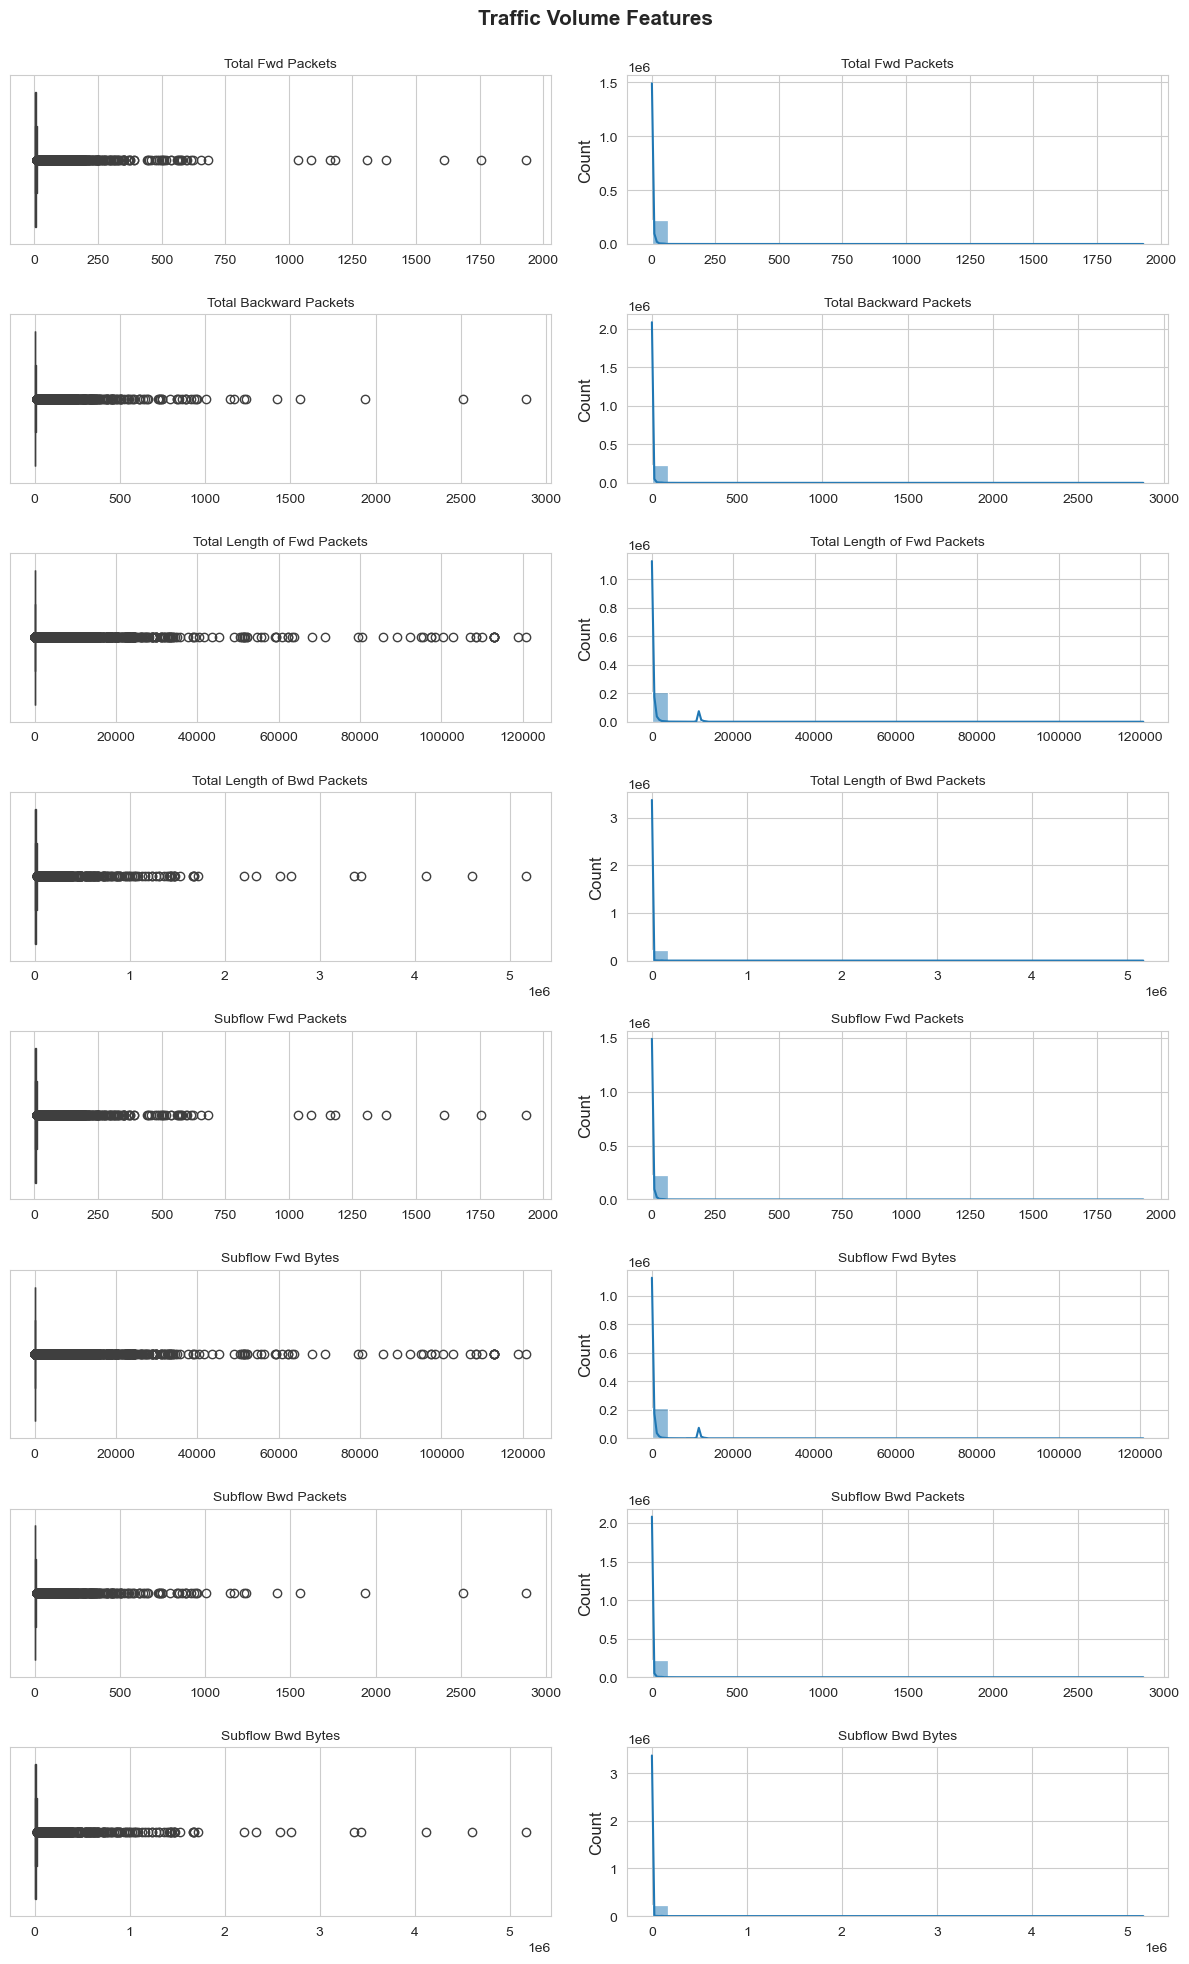

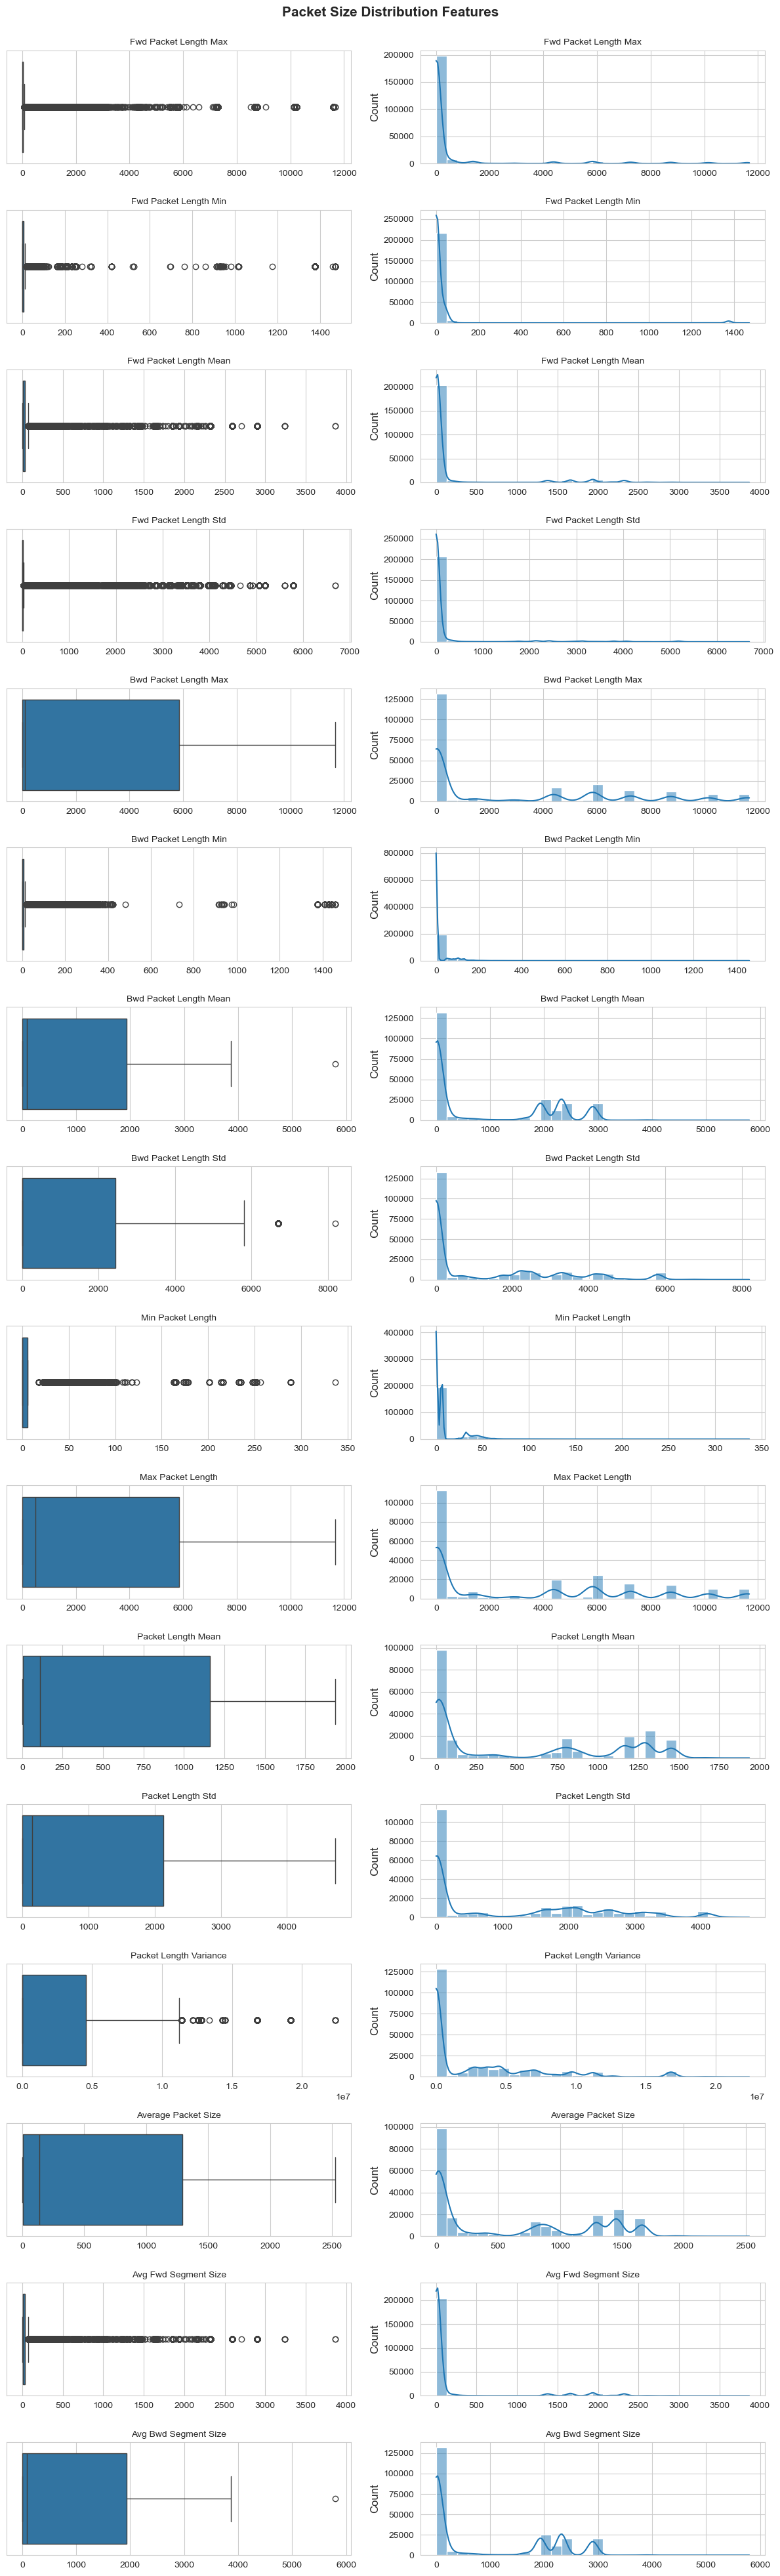

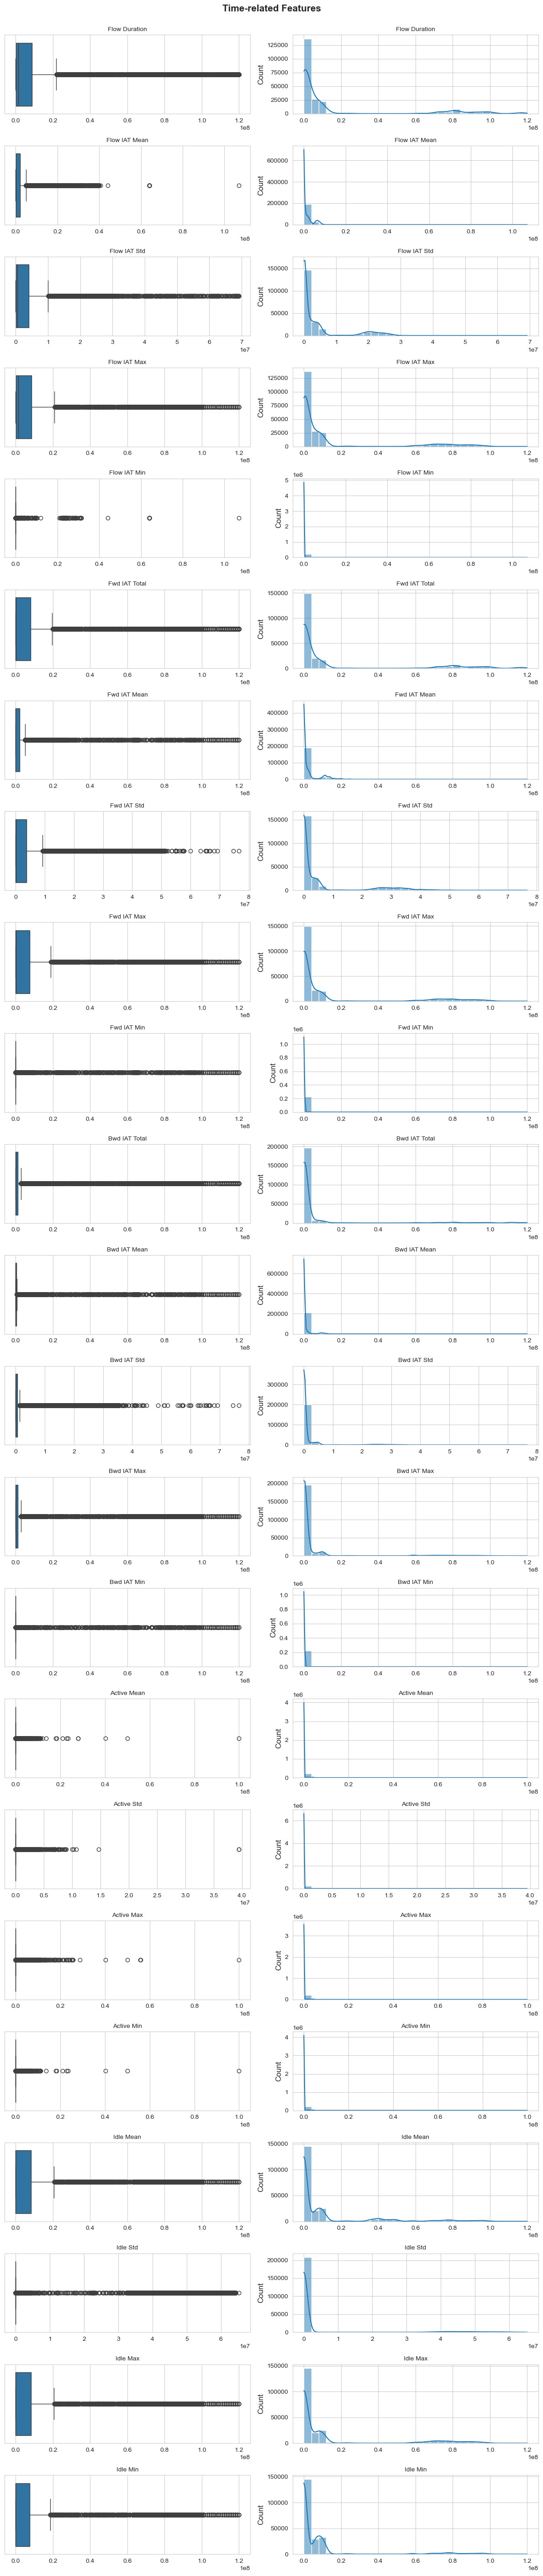

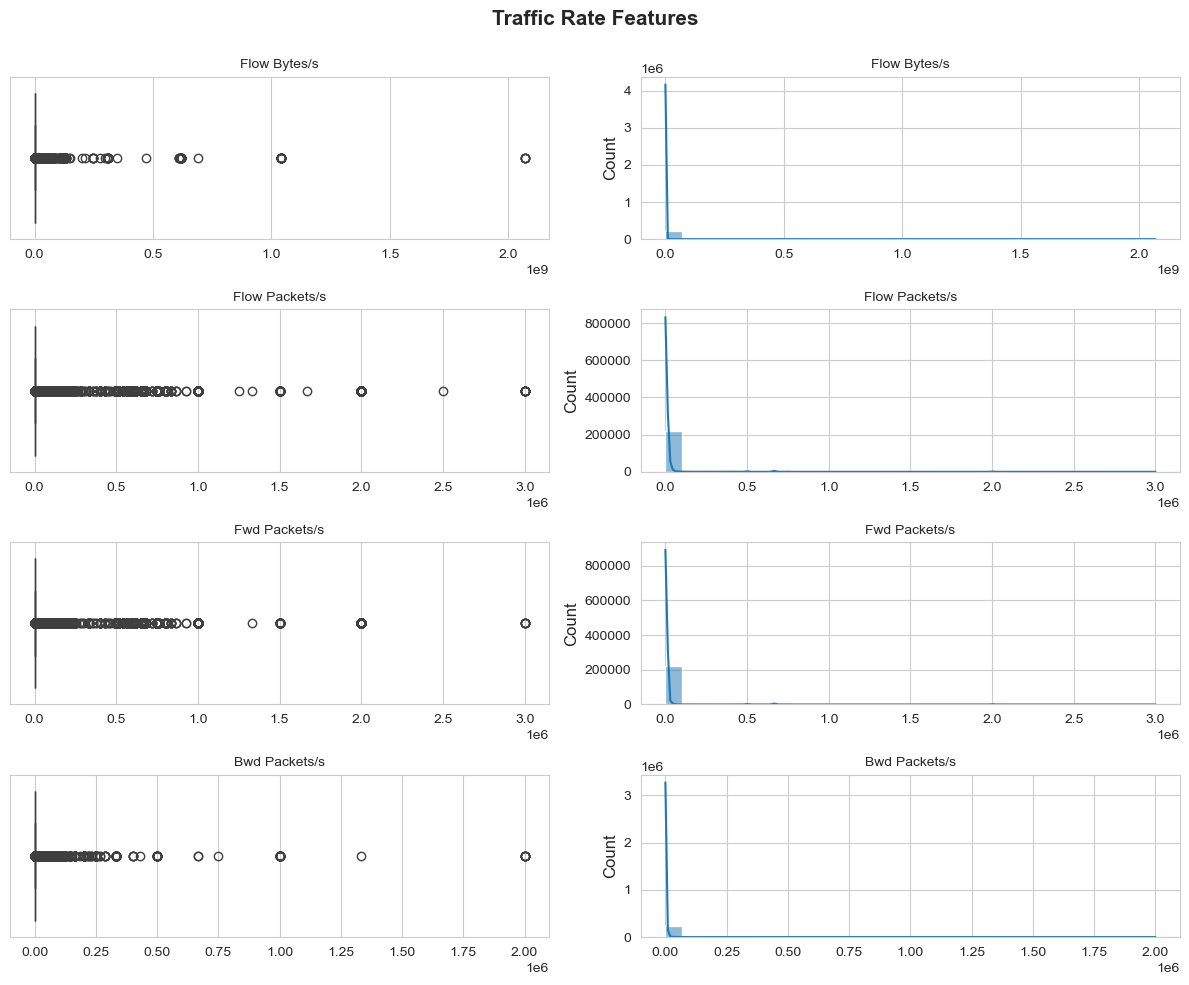

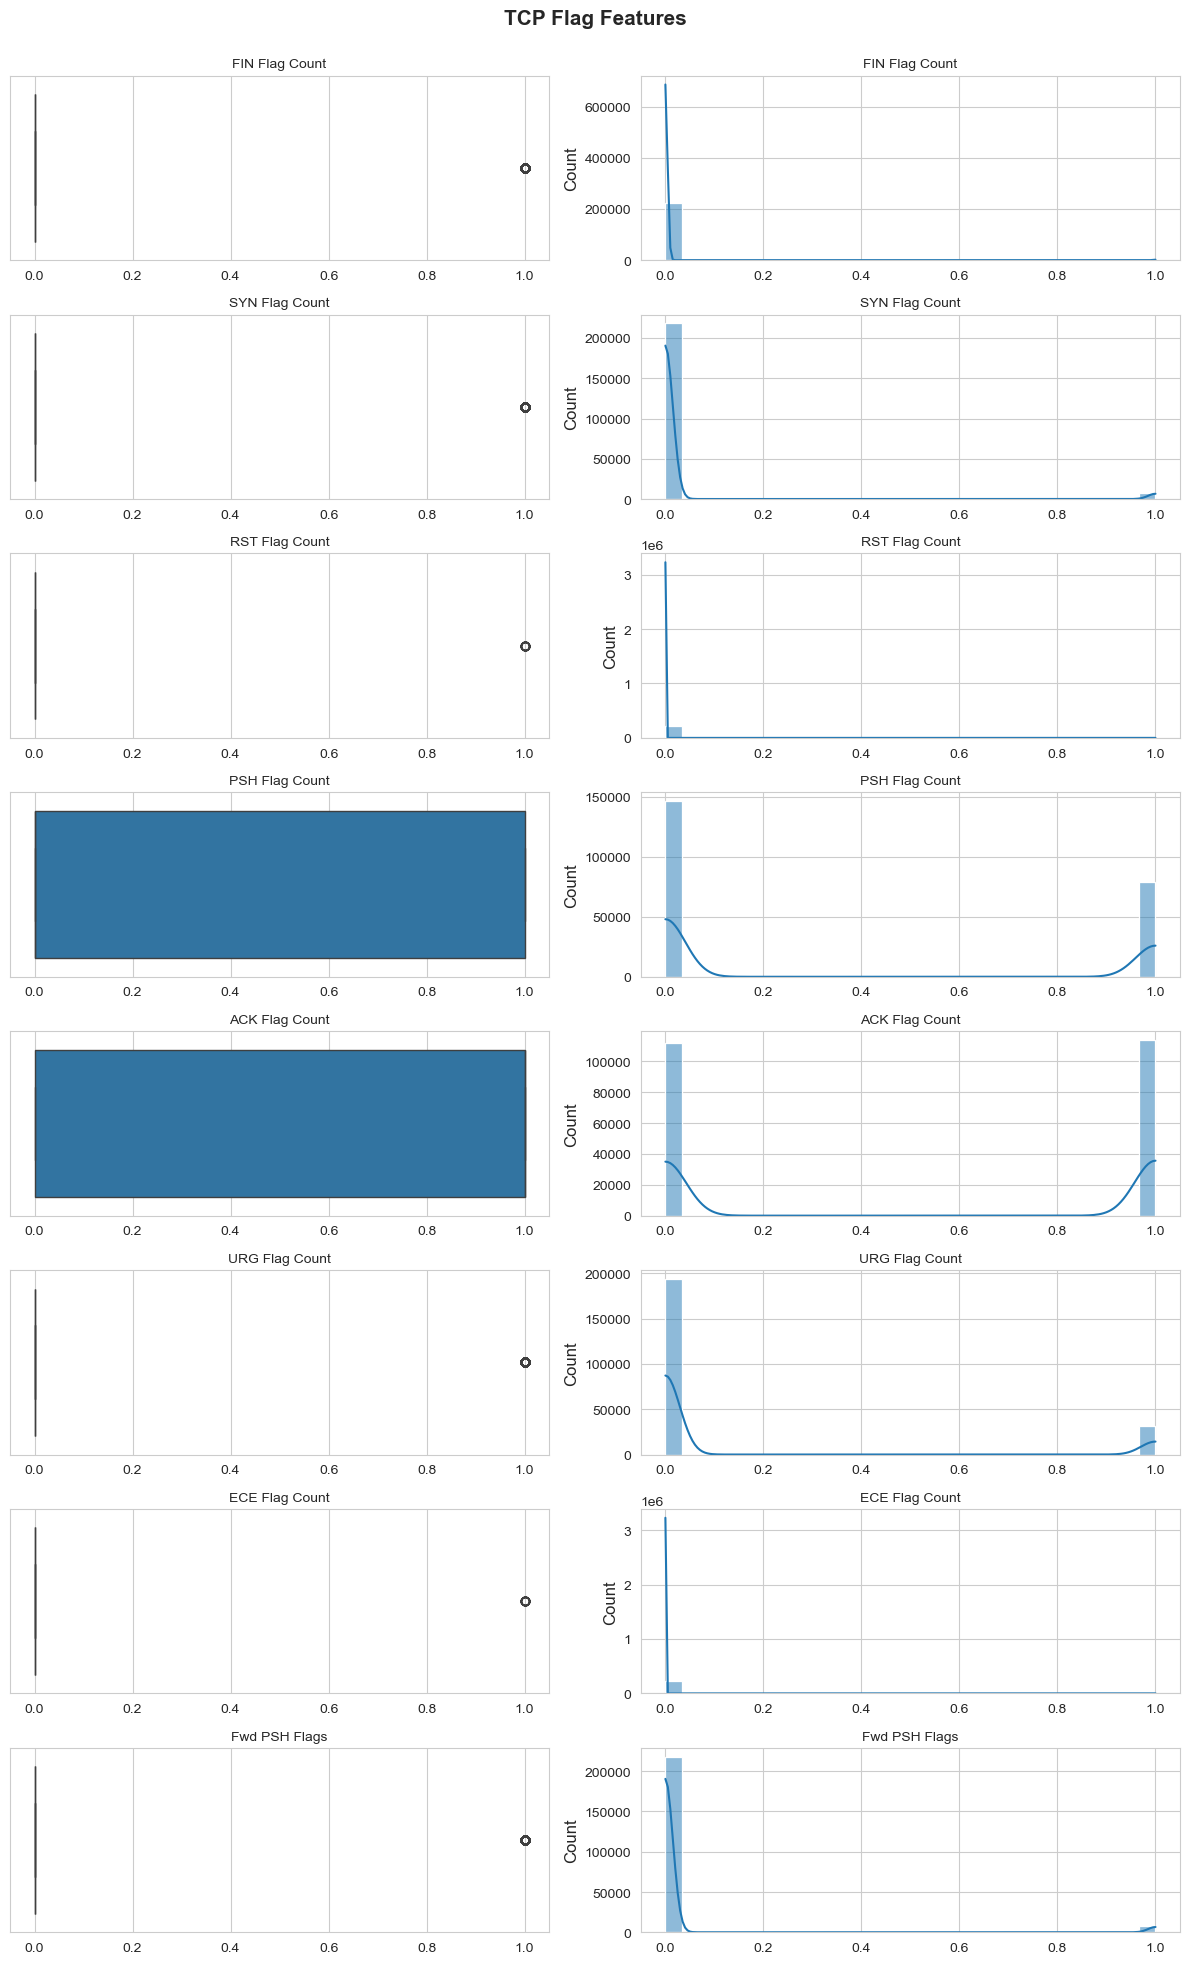

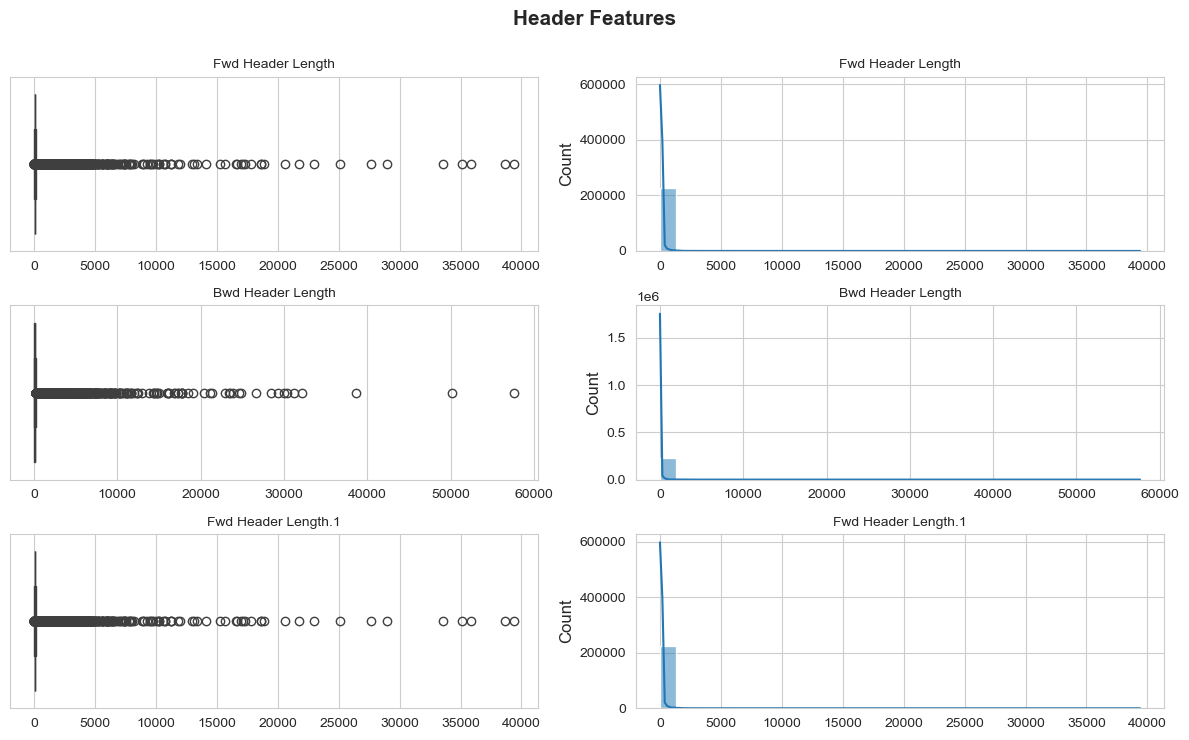

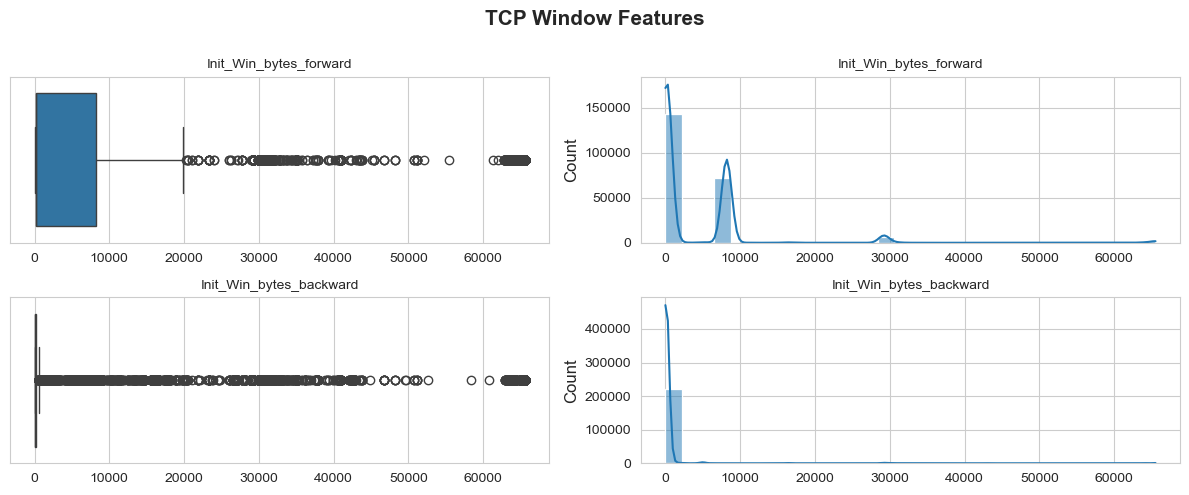

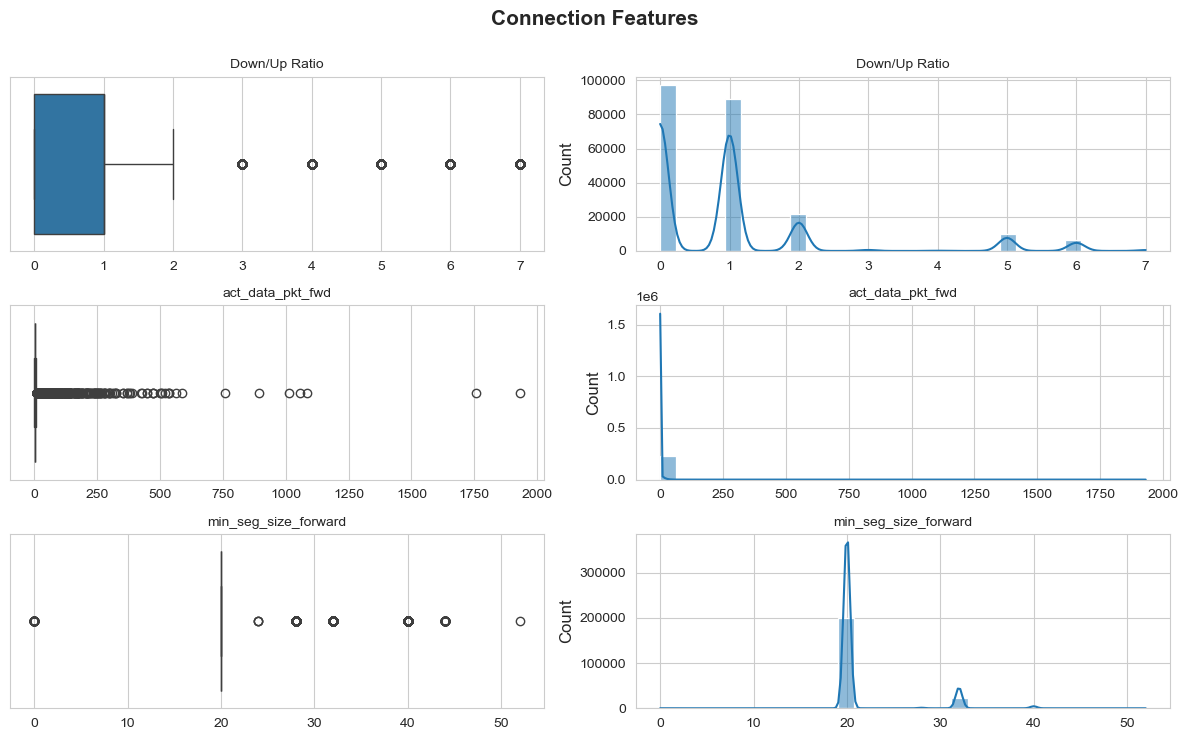

In [ ]:
def outlier_analysis(df, features_groups):
    if features_groups is None:
        raise ValueError("features_groups or target is None. Please provide valid values for both parameters.") 
    
    # Avoid modifying original data
    data = df.copy()
    for group_name, features in features_groups.items():

        # Keep only features that exist in the DataFrame
        valid_features = [f for f in features if f in data.columns]

        # Skip empty groups
        if len(valid_features) == 0:
            continue

        rows = len(valid_features)

        fig, axs = plt.subplots(
            rows,
            2,
            figsize=(12, rows * 2.5),
            squeeze=False
        )

        for i, feature in enumerate(valid_features):

            values = data[feature]

            # Boxplot
            sns.boxplot(
                x=values,
                ax=axs[i, 0]
            )
            axs[i, 0].set_title(feature, fontsize=10)
            axs[i, 0].set_xlabel("")

            # Histogram + KDE
            sns.histplot(
                values,
                bins=30,
                kde=True,
                ax=axs[i, 1]
            )
            axs[i, 1].set_title(feature, fontsize=10)
            axs[i, 1].set_xlabel("")

        fig.suptitle(
            group_name,
            fontsize=15,
            fontweight="bold"
        )

        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

outlier_analysis(full_df, traffic_feature_groups)

**Key Takeaway**: many boxplots present a right-skewed data (median closer to Q1). A **logarithmic transformation** is required to compress the range of the selected variables and reduce the influence of extreme values. 